<a href="https://colab.research.google.com/github/Mugetsu-Nuckie/dzstatprac/blob/main/knn_dz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework

The quality of classification/regression by the k Nearest Neighbors method depends on several parameters:
* the number of neighbors `n_neighbors`
* the distance metric between objects `metric`
* the weights of neighbors (the neighbors of the test example can enter with different weights, for example, the further the example, the less its "voice" is taken into account) `weights`


Train the `KNeighborsClassifier` on the dataset.

In [9]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
all_data = pd.read_csv('/data/forest_dataset.csv')
all_data.head()
all_data.shape
labels = all_data[all_data.columns[-1]].values
feature_matrix = all_data[all_data.columns[:-1]].values
feature_matrix
train_feature_matrix, test_feature_matrix, train_labels, test_labels = train_test_split(
    feature_matrix, labels, test_size=0.2, random_state=42)
clf = LogisticRegression(C=1)
clf.fit(train_feature_matrix, train_labels)
y_pred = clf.predict(test_feature_matrix)
clf = KNeighborsClassifier()
clf.fit(train_feature_matrix, train_labels)
y_pred = clf.predict(test_feature_matrix)
print(f"Accuracy baseline: {accuracy_score(test_labels, y_pred)}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy baseline: 0.7365


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Let's select the parameters of our model:

* Iterate over the grid from `1` to `10` for the number of neighbors parameter
* Also, try using different metrics: `['manhattan', 'euclidean']`
* Try using different weight calculation strategies: `[‘uniform’, ‘distance’]`

In [10]:
from sklearn.model_selection import GridSearchCV
import numpy as np
params = {
    'n_neighbors': np.arange(1, 11),'metric': ['manhattan', 'euclidean'],'weights': ['uniform', 'distance']
}
clf_grid = GridSearchCV(clf, params, cv=5, scoring='accuracy', n_jobs=-1)
clf_grid.fit(train_feature_matrix, train_labels)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['manhattan', 'euclidean'],
                         'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

Let's output the best parameters

In [11]:
print(clf_grid.best_params_)

{'metric': 'manhattan', 'n_neighbors': np.int64(4), 'weights': 'distance'}


Using the optimal number of neighbors found, calculate the probabilities of belonging to classes for the test sample (`.predict_proba`).

In [12]:
optimal_clf = clf_grid.best_estimator_
pred_prob = optimal_clf.predict_proba(test_feature_matrix)

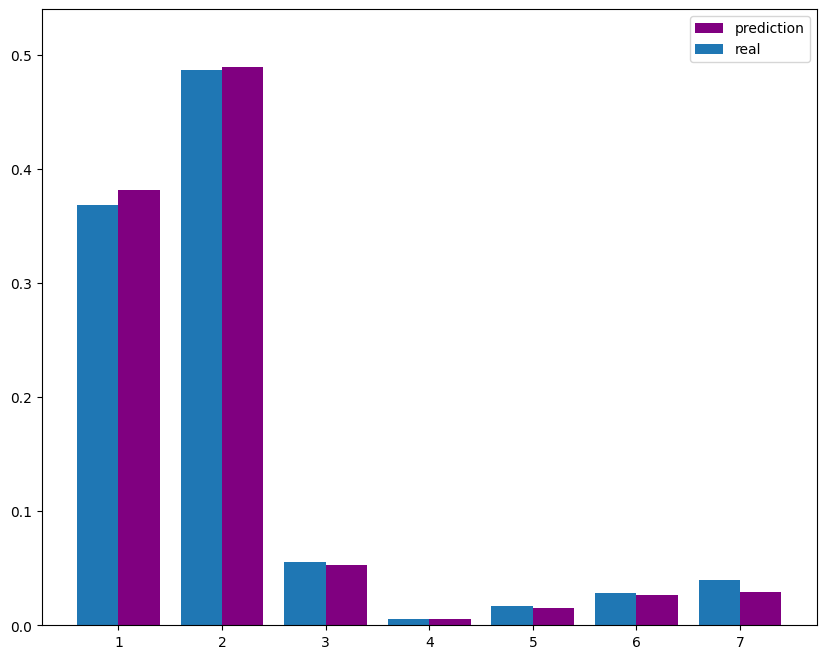

In [13]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

unique, freq = np.unique(test_labels, return_counts=True)
freq = list(map(lambda x: x / len(test_labels), freq))

pred_freq = pred_prob.mean(axis=0)

plt.figure(figsize=(10, 8))
plt.bar(range(1, 8), pred_freq, width=0.4,color='purple', align="edge", label='prediction')
plt.bar(range(1, 8), freq, width=-0.4, align="edge", label='real')
plt.ylim(0, 0.54)
plt.legend()
plt.show()

## Conclusion

What is the quality of the model on the test sample? Compare it with the quality of logistic regression. Which model is better? Why? What are the pros and cons of the k Nearest Neighbors method? Plot the ROC curve for the k Nearest Neighbors method. Calculate the area under the ROC curve (AUC-ROC).

In [14]:
test_accuracy = accuracy_score(test_labels, optimal_clf.predict(test_feature_matrix))
print(f"KNN Test Accuracy: {test_accuracy}")

KNN Test Accuracy: 0.7845


kNN покажет лучшее качество на этом датасете. Потому что датасет Covertype содержит много закодированных признаков и нелинейные зависимости. kNN хорошо работает с такими данными так как не делает предположений о линейной разделимости. Но kNN плохо работает по масштабу признаков, а тут признаки имеют разные масштабы,и это может быть минусом без нормализации.
Плюсы:
Простота реализации и понимания.
Нет фазы обучения.(просто запоминает данные)
Хорошо работает на многоклассовых задачах.
Легко адаптируется к новым данным.(не надо переобучать)
Минусы:
Медленное предсказание на больших данных.(нужно считать расстояния до всех объектов)
Требует много памяти для хранения обучающей выборки.
Чувствителен к шуму и выбросам.
Чувствителен к масштабу признаков.(требуется нормализация/стандартизация)
Плохо работает в пространствах высокой размерности.


Micro-average AUC-ROC: 0.9559


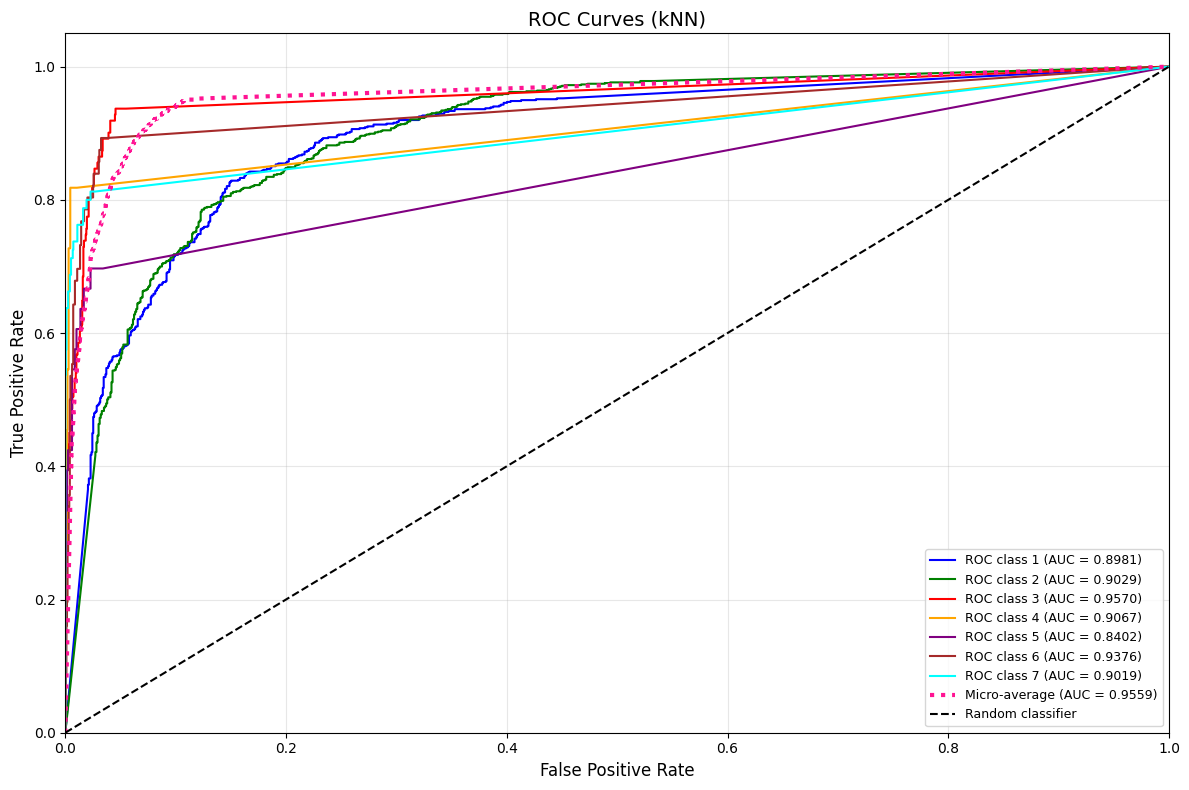

In [15]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

classes = np.unique(train_labels)
test_labels_bin = label_binarize(test_labels, classes=classes)
n_classes = len(classes)

y_score = optimal_clf.predict_proba(test_feature_matrix)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(test_labels_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

print(f"Micro-average AUC-ROC: {roc_auc['micro']:.4f}")

plt.figure(figsize=(12, 8))

colors = ['blue', 'green', 'red', 'orange', 'purple', 'brown', 'cyan']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f'ROC class {classes[i]} (AUC = {roc_auc[i]:.4f})')

plt.plot(fpr["micro"], tpr["micro"],
         label=f'Micro-average (AUC = {roc_auc["micro"]:.4f})',
         color='deeppink', linestyle=':', linewidth=3)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves (kNN)', fontsize=14)
plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()